In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "day_of_year": np.random.randint(1, 366, n),
    "hour": np.random.randint(0, 24, n),
    "humidity": np.random.uniform(30, 100, n),
    "pressure": np.random.uniform(980, 1035, n),
    "wind_speed": np.random.uniform(0, 15, n)
})

In [3]:

# Symulujemy temperaturę:
# - sezonowość roczna
# - rytm dobowy
# - wpływ wilgotności, ciśnienia i wiatru
# - losowy szum

seasonal_effect = 12 * np.sin(2 * np.pi * (data["day_of_year"] - 80) / 365)
daily_effect = 5 * np.sin(2 * np.pi * (data["hour"] - 6) / 24)

temperature = (
    10
    + seasonal_effect
    + daily_effect
    - 0.04 * data["humidity"]
    + 0.03 * (data["pressure"] - 1000)
    - 0.3 * data["wind_speed"]
    + np.random.normal(0, 2, n)
)

data["temperature"] = temperature

In [4]:
# ---------------------------------------------------------
# 2. Przygotowanie cech X i zmiennej docelowej y
# ---------------------------------------------------------

X = data[["day_of_year", "hour", "humidity", "pressure", "wind_speed"]]
y = data["temperature"]


# ---------------------------------------------------------
# 3. Podział na zbiór treningowy i testowy
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [5]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
y_pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 3))

MAE: 2.01
RMSE: 2.49
R2: 0.933


In [8]:
results = pd.DataFrame({
    "Real temperature": y_test.values,
    "Predicted temperature": y_pred
})

print(results.head(10))

   Real temperature  Predicted temperature
0          9.547583              13.186311
1         -1.124441               0.895621
2         20.523324              17.045328
3         17.910492              15.184338
4        -11.654672              -9.716743
5          8.687048              12.471989
6         12.166352               8.192226
7          6.723132               8.930928
8         11.518613              14.681710
9        -13.779123              -9.117129


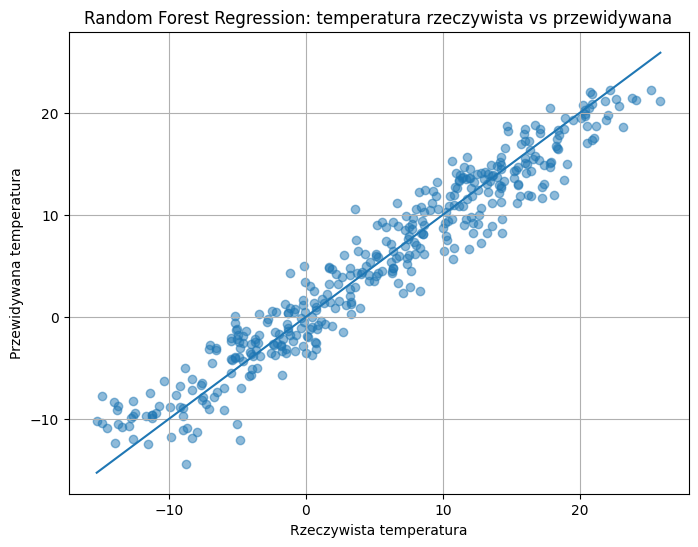

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Rzeczywista temperatura")
plt.ylabel("Przewidywana temperatura")
plt.title("Random Forest Regression: temperatura rzeczywista vs przewidywana")

min_temp = min(y_test.min(), y_pred.min())
max_temp = max(y_test.max(), y_pred.max())
plt.plot([min_temp, max_temp], [min_temp, max_temp])

plt.grid(True)
plt.show()

       feature  importance
0  day_of_year    0.820283
1         hour    0.121191
4   wind_speed    0.028525
2     humidity    0.016992
3     pressure    0.013010


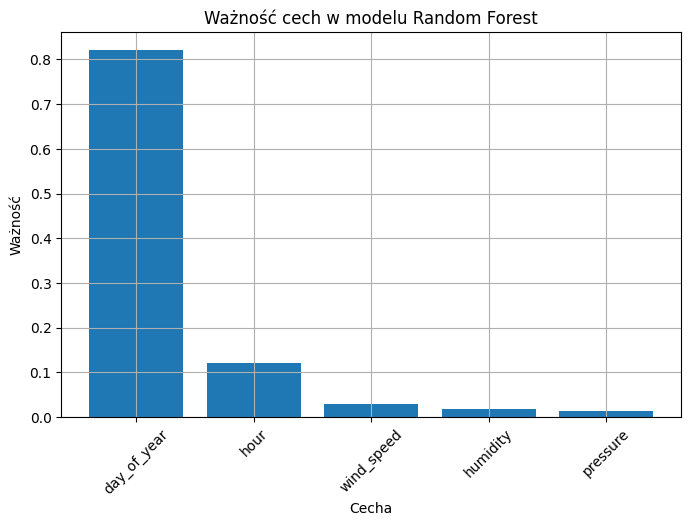

In [10]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Cecha")
plt.ylabel("Ważność")
plt.title("Ważność cech w modelu Random Forest")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()